Epoch 1/100, D Loss: 0.9969, G Loss: 1.3459
Epoch 2/100, D Loss: 1.1526, G Loss: 0.6915
Epoch 3/100, D Loss: 1.0900, G Loss: 0.6613
Epoch 4/100, D Loss: 1.0119, G Loss: 0.7343
Epoch 5/100, D Loss: 0.9940, G Loss: 0.8480
Epoch 6/100, D Loss: 0.9502, G Loss: 0.9402
Epoch 7/100, D Loss: 1.0007, G Loss: 1.0156
Epoch 8/100, D Loss: 0.9390, G Loss: 1.0721
Epoch 9/100, D Loss: 0.8448, G Loss: 1.0861
Epoch 10/100, D Loss: 0.8482, G Loss: 1.2053
Epoch 11/100, D Loss: 0.7449, G Loss: 1.2956
Epoch 12/100, D Loss: 0.8353, G Loss: 1.2351
Epoch 13/100, D Loss: 0.9253, G Loss: 1.0296
Epoch 14/100, D Loss: 0.8598, G Loss: 1.2848
Epoch 15/100, D Loss: 0.9470, G Loss: 1.1747
Epoch 16/100, D Loss: 0.7404, G Loss: 1.3148
Epoch 17/100, D Loss: 0.7760, G Loss: 1.3243
Epoch 18/100, D Loss: 0.7544, G Loss: 1.3462
Epoch 19/100, D Loss: 0.9220, G Loss: 1.1848
Epoch 20/100, D Loss: 1.1083, G Loss: 1.0661
Epoch 21/100, D Loss: 0.7662, G Loss: 1.5320
Epoch 22/100, D Loss: 0.8482, G Loss: 1.1584
Epoch 23/100, D Los

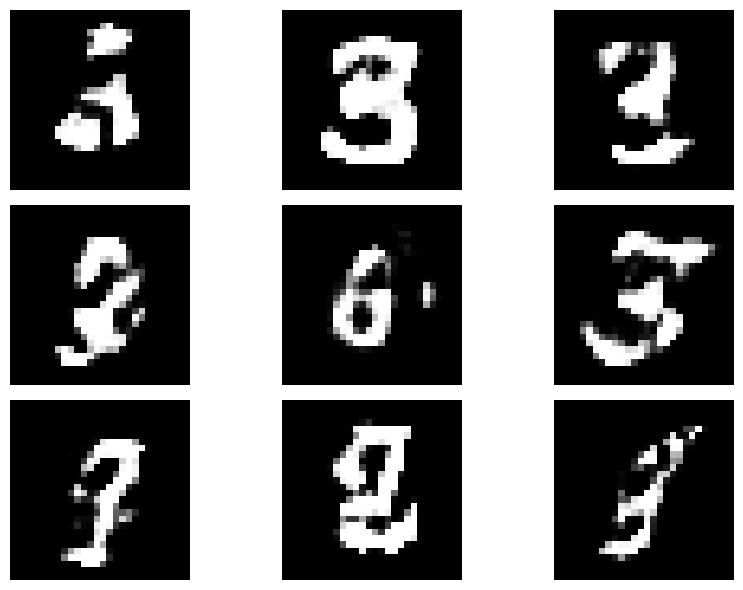

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# 设置设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 数据加载与预处理
transform = transforms.ToTensor()
train_dataset = MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=60, shuffle=True)

# 生成器定义
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.Linear(100, 64),
            nn.ReLU(True),
            nn.Linear(64, 28*28),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.main(x)
        return x.view(-1, 1, 28, 28)

# 判别器定义，使用 sigmoid(logits / scale)
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x, scale=0.01):
        logits = self.main(x)
        scale = scale.view(-1, 1)
        return torch.sigmoid(logits / scale)

# 初始化模型与优化器
generator = Generator().to(device)
discriminator = Discriminator().to(device)

optimizer_g = optim.Adam(generator.parameters(), lr=0.0001, betas=(0.5, 0.999))
optimizer_d = optim.Adam(discriminator.parameters(), lr=0.0001, betas=(0.5, 0.999))
criterion = nn.BCELoss()

# 固定缩放因子
fixed_sigma = 3.0

# 训练
epochs = 100
for epoch in range(epochs):
    for images, _ in train_loader:
        images = images.to(device)
        batch_size = images.size(0)
        scale = torch.full((batch_size, 1), fixed_sigma, device=device)

        # 训练判别器
        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        discriminator.zero_grad()
        real_output = discriminator(images, scale)
        d_loss_real = criterion(real_output, real_labels)

        noise = torch.randn(batch_size, 100, device=device)
        fake_images = generator(noise)
        fake_output = discriminator(fake_images.detach(), scale)
        d_loss_fake = criterion(fake_output, fake_labels)

        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_d.step()

        # 训练生成器
        generator.zero_grad()
        fake_output = discriminator(fake_images, scale)
        g_loss = criterion(fake_output, real_labels)
        g_loss.backward()
        optimizer_g.step()

    print(f"Epoch {epoch+1}/{epochs}, D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}")

# 展示生成图像
generator.eval()
with torch.no_grad():
    test_noise = torch.randn(9, 100, device=device)
    generated = generator(test_noise).cpu().numpy()
    generated = generated.squeeze(1)

plt.figure(figsize=(9, 6))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(generated[i], cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()
